# Agent Skills Guide

This notebook demonstrates the **agent skills pattern** — a mechanism for giving agents on-demand knowledge that shapes how they reason, without permanently bloating their context.

We progress through four stages:

1. **Basic agent** — built-in filesystem tools, no skills. Works, but reasons naively.
2. **Skills in memory** — skills defined as Python dicts, loaded via a tool. Agent reasons better.
3. **Skills on filesystem** — skills stored as `SKILL.md` files (Claude Code style). Same mechanism, portable format.
4. **SkillMiddleware** — a proper middleware class that auto-discovers skills and injects them cleanly.

The domain (filesystem exploration) is deliberately simple. The focus is on **how skills work**, not what the agent does.

### References

- [Equipping agents for the real world with Agent Skills](https://claude.com/blog/equipping-agents-for-the-real-world-with-agent-skills) — Anthropic blog
- [Prebuilt middleware](https://docs.langchain.com/oss/python/langchain/middleware/built-in) — LangChain built-in middleware
- [Custom middleware](https://docs.langchain.com/oss/python/langchain/middleware/custom) — LangChain custom middleware

## Skills vs Tools

This distinction is the core idea of the project.

| | **Tools** | **Skills** |
|---|---|---|
| **What they are** | Executable functions | Structured knowledge |
| **What they do** | Perform actions (read a file, search, execute shell) | Teach the agent how to reason about a task |
| **When loaded** | Always available | On demand, when the agent decides it needs guidance |
| **Analogy** | A screwdriver | A repair manual |

A skill is closer to a runbook, a checklist, or a decision framework — not a function call.

Skills contain **guidelines and heuristics**. For example, a `filesystem_navigation` skill doesn't list files — it teaches the agent *which* files to look at first, what to avoid, and how to build a mental map of a project.

In [50]:
from dotenv import load_dotenv
import os

if load_dotenv():
    print("✅ Environment loaded successfully")
else:
    print("⚠️ No .env file found; relying on existing environment")

for env_var in ("OPENAI_API_KEY", "LANGCHAIN_TRACING_V2", "LANGCHAIN_API_KEY", "LANGCHAIN_PROJECT"):
    status = "SET" if os.getenv(env_var) else "NOT SET"
    print(f"{env_var}: {status}")

⚠️ No .env file found; relying on existing environment
OPENAI_API_KEY: SET
LANGCHAIN_TRACING_V2: SET
LANGCHAIN_API_KEY: SET
LANGCHAIN_PROJECT: NOT SET


In [ ]:
model = "gpt-5-mini"

In [52]:
from pathlib import Path

# Paths used throughout the notebook
PROJECT_ROOT = Path(".").resolve()
SAMPLE_PROJECT = PROJECT_ROOT / "sample_project"
SKILLS_DIR = PROJECT_ROOT / "skills"

print(f"Project root:    {PROJECT_ROOT}")
print(f"Sample project:  {SAMPLE_PROJECT}")
print(f"Skills dir:      {SKILLS_DIR}")

Project root:    /Users/esurovtsev/Projects/learning/LangChain Guides/langchain-agent-skills
Sample project:  /Users/esurovtsev/Projects/learning/LangChain Guides/langchain-agent-skills/sample_project
Skills dir:      /Users/esurovtsev/Projects/learning/LangChain Guides/langchain-agent-skills/skills


In [82]:
import sys
from pathlib import Path

experiments_root = str(Path("..").resolve())
if experiments_root not in sys.path:
    sys.path.append(experiments_root)

from notebook_helpers import run_agent

# The test prompt we'll use throughout — same prompt, different agent configs
TEST_PROMPT = (
    f"Explore the project at {SAMPLE_PROJECT}. "
    "Tell me what it is and whether its configuration looks correct."
)

## 1. Basic Agent (No Skills)

First, let's create an agent with **only built-in middleware** — filesystem access and file search. No skills at all.

The agent can explore files, but it has no guidance on *how* to approach the task. It will work, but watch how it reasons — it may miss important files, read things in a suboptimal order, or provide a shallow analysis.

We use two built-in middleware:
- **`FilesystemMiddleware`** — provides `ls`, `read_file`, `write_file`, `edit_file`
- **`FilesystemFileSearchMiddleware`** — provides `glob_search`, `grep_search`

In [78]:
from langchain.agents import create_agent
from langchain.agents.middleware import FilesystemFileSearchMiddleware
from deepagents.middleware.filesystem import FilesystemMiddleware
from deepagents.backends.filesystem import FilesystemBackend
from langgraph.checkpoint.memory import InMemorySaver

basic_agent = create_agent(
    model,
    system_prompt=(
        "You are a project analyst. When asked about a project, "
        "explore its files and provide a structured analysis."
    ),
    middleware=[
        FilesystemMiddleware(backend=FilesystemBackend()),
        FilesystemFileSearchMiddleware(
            root_path=str(PROJECT_ROOT),
        ),
    ],
    checkpointer=InMemorySaver(),
)

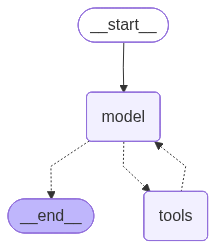

In [55]:
from IPython.display import Image, display

# Visualize the agent's graph structure
display(Image(basic_agent.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
# Run the basic agent — no skills, just tools
run_agent(basic_agent, TEST_PROMPT)

================================== Ai Message ==================================
Tool Calls:
  ls (call_MzrfQqslR7oYOdy5JbcyENCU)
 Call ID: call_MzrfQqslR7oYOdy5JbcyENCU
  Args:
    path: /Users/esurovtsev/Projects/learning/LangChain Guides/langchain-agent-skills/sample_project
================================= Tool Message =================================
Name: ls

['/Users/esurovtsev/Projects/learning/LangChain Guides/langchain-agent-skills/sample_project/.DS_Store', '/Users/esurovtsev/Projects/learning/LangChain Guides/langchain-agent-skills/sample_project/.env.example', '/Users/esurovtsev/Projects/learning/LangChain Guides/langchain-agent-skills/sample_project/README.md', '/Users/esurovtsev/Projects/learning/LangChain Guides/langchain-agent-skills/sample_project/backend/', '/Users/esurovtsev/Projects/learning/LangChain Guides/langchain-agent-skills/sample_project/frontend/']
================================== Ai Message ==================================
Tool Calls:
  ls (call_vzK

### Observation

The agent can list files and read them, but it has no **strategy**. It doesn't know:
- Which files to look at first (README? config? entry point?)
- How to classify files by role (entry point vs utility vs model)
- What to avoid (reading `.env`, diving into `__pycache__`)
- How to structure its analysis for a developer audience

It has **tools** but no **knowledge about how to use them well**.

This is what skills fix.

## 2. Skills In Memory

Now let's add skills. In this first version, skills are plain Python dicts stored in memory.

Each skill has:
- **`name`** — unique identifier
- **`description`** — short summary, shown in the system prompt
- **`content`** — full knowledge, loaded only when the agent asks for it

The agent sees only the descriptions initially. It decides which skill(s) to load based on the task.

In [59]:
from typing import TypedDict


class Skill(TypedDict):
    """A skill that can be progressively disclosed to the agent."""
    name: str          # Unique identifier
    description: str   # 1-2 sentence description shown in system prompt
    content: str       # Full skill content loaded on demand


SKILLS: list[Skill] = [
    {
        "name": "filesystem_navigation",
        "description": "Guidelines for systematically exploring and understanding directory structures.",
        "content": """# Filesystem Navigation

## Strategy

### Start at the Root
Always begin by listing the top-level directory. The root reveals the project type:
- README.md → start here, it's the author's own summary
- requirements.txt, pyproject.toml, package.json → language and dependencies
- Dockerfile, docker-compose.yml → containerized project
- .env.example → environment variables needed (never read .env itself)

### Explore Breadth Before Depth
List all top-level directories before diving into any single one:
- src/ or app/ → application code
- tests/ → test suite
- config/ → configuration
- docs/ → documentation

### Go Deeper with Purpose
Don't read every file. Choose based on what you're trying to answer:
- What it does → README, then entry point
- How it's structured → list src/ recursively
- How to run it → README, Makefile, Dockerfile, config

## Things to Avoid
- Don't assume a file's purpose from its name alone
- Don't read binary files or .env files
- Don't read node_modules/, __pycache__/, .git/
""",
    },
    {
        "name": "config_file_recognition",
        "description": "How to find, read, and audit configuration files — includes concrete investigation steps like grepping for env vars, checking for hardcoded secrets, and mapping external service dependencies.",
        "content": """# Config File Recognition

## Step-by-Step Investigation

### Step 1: Find All Config Files
Use glob_search to locate config files across the project:
- glob_search(pattern="**/.env*") — environment files
- glob_search(pattern="**/*.json", path="config/") — JSON config
- glob_search(pattern="**/requirements*.txt") — Python dependencies
- glob_search(pattern="**/package.json") — Node.js dependencies

### Step 2: Read Safe Config Files First
1. .env.example — safe to read, shows what variables the app expects
2. config/ directory files — JSON/YAML config for services, servers
3. requirements.txt / package.json — dependencies reveal what services are used

Never read .env files — they may contain real secrets.

### Step 3: Grep for Configuration Patterns in Code
Use grep_search to understand how config is consumed:
- grep_search(query="os.getenv|os.environ|dotenv") — env var usage in Python
- grep_search(query="process.env") — env var usage in JavaScript
- grep_search(query="localhost|127.0.0.1") — hardcoded local URLs
- grep_search(query="SECRET|KEY|TOKEN|PASSWORD") — sensitive values in code

### Step 4: Map External Dependencies
From config files and grep results, build a picture of:
- Required environment variables — list each with its purpose
- External services — databases, APIs, caches
- Ports — what the app listens on and connects to

### Step 5: Check for Issues
- Hardcoded secrets — API keys or passwords directly in source code
- Missing .env.example — code uses env vars but no example documents them
- Inconsistent ports — frontend configured for one port, backend on another
- Hardcoded URLs — localhost or IPs that won't work in production
- Unpinned dependencies — requirements.txt without version pins

## Things to Avoid
- Never read .env files — they contain real secrets
- Never display actual secret values even if found in code
- Don't assume config values are current
""",
    },
]

In [60]:
from langchain.tools import tool


@tool
def load_skill(skill_name: str) -> str:
    """Load the full content of a skill into the agent's context.

    Use this when you need detailed guidance on how to approach a specific
    type of task. Skills contain reasoning strategies, heuristics, and
    guidelines — not actions.

    Args:
        skill_name: The name of the skill to load.
    """
    for s in SKILLS:
        if s["name"] == skill_name:
            return f"Loaded skill: {skill_name}\n\n{s['content']}"

    available = ", ".join(s["name"] for s in SKILLS)
    return f"Skill '{skill_name}' not found. Available skills: {available}"

Now we create the agent with:
- The same built-in middleware (filesystem tools)
- The `load_skill` tool added
- A system prompt that lists skill descriptions (manually injected for now)

In [64]:
# Build the skill catalog for the system prompt
skill_catalog = "\n".join(
    f"- **{s['name']}**: {s['description']}" for s in SKILLS
)

system_prompt_with_skills = (
    "You are a project analyst. When asked about a project, "
    "explore its files and provide a structured analysis.\n\n"
    "## Available Skills\n\n"
    f"{skill_catalog}\n\n"
    "Before starting each phase of your work, load the relevant skill "
    "using the load_skill tool. Skills contain expert strategies and "
    "step-by-step guidelines you should follow. "
    "Don't skip loading a skill just because the task seems familiar — "
    "the skill may contain important details you'd otherwise miss."
)

print(system_prompt_with_skills)

You are a project analyst. When asked about a project, explore its files and provide a structured analysis.

## Available Skills

- **filesystem_navigation**: Guidelines for systematically exploring and understanding directory structures.
- **config_file_recognition**: How to find, read, and audit configuration files — includes concrete investigation steps like grepping for env vars, checking for hardcoded secrets, and mapping external service dependencies.

Before starting each phase of your work, load the relevant skill using the load_skill tool. Skills contain expert strategies and step-by-step guidelines you should follow. Don't skip loading a skill just because the task seems familiar — the skill may contain important details you'd otherwise miss.


In [65]:
from langchain.agents import create_agent
from langchain.agents.middleware import FilesystemFileSearchMiddleware
from deepagents.middleware.filesystem import FilesystemMiddleware
from deepagents.backends.filesystem import FilesystemBackend
from langgraph.checkpoint.memory import InMemorySaver

skills_agent = create_agent(
    model,
    system_prompt=system_prompt_with_skills,
    tools=[load_skill],
    middleware=[
        FilesystemMiddleware(backend=FilesystemBackend()),
        FilesystemFileSearchMiddleware(
            root_path=str(PROJECT_ROOT),
        ),
    ],
    checkpointer=InMemorySaver(),
)

In [ ]:
# Run the same prompt — now with skills available
run_agent(skills_agent, TEST_PROMPT)

================================ Human Message =================================

Explore the project at /Users/esurovtsev/Projects/learning/LangChain Guides/langchain-agent-skills/sample_project. Tell me what it is and whether its configuration looks correct.
================================== Ai Message ==================================
Tool Calls:
  load_skill (call_uJzyn1gu2C10t4iXwcRV2fLO)
 Call ID: call_uJzyn1gu2C10t4iXwcRV2fLO
  Args:
    skill_name: filesystem_navigation
================================= Tool Message =================================
Name: load_skill

Loaded skill: filesystem_navigation

# Filesystem Navigation

## Strategy

### Start at the Root
Always begin by listing the top-level directory. The root reveals the project type:
- README.md → start here, it's the author's own summary
- requirements.txt, pyproject.toml, package.json → language and dependencies
- Dockerfile, docker-compose.yml → containerized project
- .env.example → environment variables needed

### Observation

Compare this with the basic agent run above. Look for:
- Did the agent **load any skills** before exploring?
- Did it follow a more **systematic strategy** (e.g., README first, then structure)?
- Is the final analysis more **structured and developer-friendly**?

The agent has the same tools. The difference is **knowledge about how to use them**.

Note: the skills are still Python dicts in memory. Next, we move them to the filesystem.

## 3. Skills on the Filesystem

Now we store skills as files on disk, following the [Claude Code / Agent Skills convention](https://claude.com/blog/equipping-agents-for-the-real-world-with-agent-skills):

```
skills/
├── filesystem_navigation/
│   └── SKILL.md
└── config_file_recognition/
    └── SKILL.md
```

Each `SKILL.md` starts with YAML frontmatter containing `name` and `description`. The body contains the full skill content.

This enables **progressive disclosure**:
1. **Level 1**: Agent sees skill name + description (in system prompt)
2. **Level 2**: Agent loads full `SKILL.md` content (via `load_skill`)
3. **Level 3**: A skill can reference additional files in its directory (e.g., `patterns.md`, `examples.md`) that the agent reads via `read_file` for even deeper detail. *This level is outside the scope of this guide, but the mechanism is straightforward — just add files and reference them from `SKILL.md`.*

The skill files already exist in the `skills/` directory. Let's scan them.

In [70]:
import yaml

def scan_skills(skills_dir: Path) -> list[dict]:
    """Scan a directory for skills. Reads only YAML frontmatter (name + description).

    Returns a list of dicts with 'name', 'description', and 'path' (to SKILL.md).
    """
    skills = []
    for skill_md in sorted(skills_dir.glob("*/SKILL.md")):
        text = skill_md.read_text()

        # Parse YAML frontmatter (between --- delimiters)
        if text.startswith("---"):
            _, frontmatter, body = text.split("---", 2)
            meta = yaml.safe_load(frontmatter)
            skills.append({
                "name": meta["name"],
                "description": meta["description"],
                "path": str(skill_md),
            })

    return skills


# Scan skills — reads only frontmatter, not full content
skill_registry = scan_skills(SKILLS_DIR)

for s in skill_registry:
    print(f"{s['name']}\n{s['description']}")
    print(f"path: {s['path']}")
    print("\n")

config_file_recognition
How to find, read, and audit configuration files — includes concrete investigation steps like grepping for env vars, checking for hardcoded secrets, and mapping external service dependencies.
path: /Users/esurovtsev/Projects/learning/LangChain Guides/langchain-agent-skills/skills/config_file_recognition/SKILL.md


filesystem_navigation
Guidelines for systematically exploring and understanding directory structures.
path: /Users/esurovtsev/Projects/learning/LangChain Guides/langchain-agent-skills/skills/filesystem_navigation/SKILL.md




In [71]:
@tool
def load_skill_from_fs(skill_name: str) -> str:
    """Load the full content of a skill from the filesystem.

    Use this when you need detailed guidance on how to approach a specific
    type of task. Skills contain reasoning strategies, heuristics, and
    guidelines — not actions.

    Args:
        skill_name: The name of the skill to load.
    """
    for s in skill_registry:
        if s["name"] == skill_name:
            # Read full file content (body after frontmatter)
            text = Path(s["path"]).read_text()
            if text.startswith("---"):
                _, _, body = text.split("---", 2)
                content = body.strip()
            else:
                content = text.strip()
            return f"Loaded skill: {skill_name}\n\n{content}"

    available = ", ".join(s["name"] for s in skill_registry)
    return f"Skill '{skill_name}' not found. Available skills: {available}"

In [72]:
# Build skill catalog from filesystem scan
fs_skill_catalog = "\n".join(
    f"- **{s['name']}**: {s['description']}" for s in skill_registry
)

fs_system_prompt = (
    "You are a project analyst. When asked about a project, "
    "explore its files and provide a structured analysis.\n\n"
    "## Available Skills\n\n"
    f"{fs_skill_catalog}\n\n"
    "Before starting each phase of your work, load the relevant skill "
    "using the load_skill_from_fs tool. Skills contain expert strategies and "
    "step-by-step guidelines you should follow. "
    "Don't skip loading a skill just because the task seems familiar — "
    "the skill may contain important details you'd otherwise miss.\n\n"
    "Some skills reference additional files in their directory — "
    "you can read those with read_file for even deeper detail."
)

print(fs_system_prompt)

You are a project analyst. When asked about a project, explore its files and provide a structured analysis.

## Available Skills

- **config_file_recognition**: How to find, read, and audit configuration files — includes concrete investigation steps like grepping for env vars, checking for hardcoded secrets, and mapping external service dependencies.
- **filesystem_navigation**: Guidelines for systematically exploring and understanding directory structures.

Before starting each phase of your work, load the relevant skill using the load_skill_from_fs tool. Skills contain expert strategies and step-by-step guidelines you should follow. Don't skip loading a skill just because the task seems familiar — the skill may contain important details you'd otherwise miss.

Some skills reference additional files in their directory — you can read those with read_file for even deeper detail.


In [73]:
from langchain.agents import create_agent
from langchain.agents.middleware import FilesystemFileSearchMiddleware
from deepagents.middleware.filesystem import FilesystemMiddleware
from deepagents.backends.filesystem import FilesystemBackend
from langgraph.checkpoint.memory import InMemorySaver

fs_agent = create_agent(
    model,
    system_prompt=fs_system_prompt,
    tools=[load_skill_from_fs],
    middleware=[
        FilesystemMiddleware(backend=FilesystemBackend()),
        FilesystemFileSearchMiddleware(
            root_path=str(PROJECT_ROOT),
        ),
    ],
    checkpointer=InMemorySaver(),
)

In [ ]:
# Run with filesystem-backed skills
run_agent(fs_agent, TEST_PROMPT)

================================ Human Message =================================

Explore the project at /Users/esurovtsev/Projects/learning/LangChain Guides/langchain-agent-skills/sample_project. Tell me what it is and whether its configuration looks correct.
================================== Ai Message ==================================
Tool Calls:
  load_skill_from_fs (call_dQ3dZMbgz4vAkX16wmYNSCZD)
 Call ID: call_dQ3dZMbgz4vAkX16wmYNSCZD
  Args:
    skill_name: filesystem_navigation
================================= Tool Message =================================
Name: load_skill_from_fs

Loaded skill: filesystem_navigation

# Filesystem Navigation

## When to Use This Skill

When you are asked to explore, understand, or map a project's file structure. This includes requests like "what is this project?", "show me the structure", or "help me find where X is".

## Strategy

### Start at the Root

Always begin by listing the top-level directory. The root reveals the project type faste

### Observation

Functionally identical to the in-memory version, but now:
- Skills are **portable files** — add a skill by creating a folder with a `SKILL.md`
- Skill content is **never hardcoded** in the agent's source code
- Adding a new skill requires zero code changes — just drop a folder into `skills/`

The remaining issue: we're still **manually building the system prompt** with skill descriptions. Let's fix that with middleware.

## 4. SkillMiddleware

Now we encapsulate the skill mechanism into a proper `AgentMiddleware` class.

The middleware:
1. **On init** — scans the `skills/` directory, reads frontmatter only
2. **On every model call** — appends the skill catalog to the system prompt via `wrap_model_call`
3. **Registers `load_skill`** as a tool via the `tools` class variable

This means the agent creator doesn't need to know anything about skills — they just add `SkillMiddleware(skills_dir)` to the middleware list.

In [75]:
from langchain.agents.middleware import AgentMiddleware, ModelRequest, ModelResponse
from langchain.messages import SystemMessage
from typing import Callable


class SkillMiddleware(AgentMiddleware):
    """Middleware that discovers skills on the filesystem and provides
    them to the agent via progressive disclosure.

    On init: scans skills_dir for SKILL.md files, reads frontmatter.
    On model call: appends skill catalog to system prompt.
    Provides: load_skill tool for on-demand loading.
    """

    def __init__(self, skills_dir: str | Path):
        super().__init__()
        self.skills_dir = Path(skills_dir)
        self.registry = self._scan_skills()
        self.skills_prompt = self._build_catalog()

        # Create the load_skill tool with access to this middleware's registry
        registry = self.registry  # capture for closure

        @tool
        def load_skill(skill_name: str) -> str:
            """Load the full content of a skill into the agent's context.

            Use this when you need detailed guidance on how to approach
            a specific type of task. Skills contain reasoning strategies,
            heuristics, and guidelines — not actions.

            Args:
                skill_name: The name of the skill to load.
            """
            for s in registry:
                if s["name"] == skill_name:
                    text = Path(s["path"]).read_text()
                    if text.startswith("---"):
                        _, _, body = text.split("---", 2)
                        content = body.strip()
                    else:
                        content = text.strip()
                    return f"Loaded skill: {skill_name}\n\n{content}"

            available = ", ".join(s["name"] for s in registry)
            return f"Skill '{skill_name}' not found. Available skills: {available}"

        self._load_skill_tool = load_skill

    @property
    def tools(self):
        return [self._load_skill_tool]

    def _scan_skills(self) -> list[dict]:
        """Scan skills directory, read only YAML frontmatter."""
        skills = []
        for skill_md in sorted(self.skills_dir.glob("*/SKILL.md")):
            text = skill_md.read_text()
            if text.startswith("---"):
                _, frontmatter, _ = text.split("---", 2)
                meta = yaml.safe_load(frontmatter)
                skills.append({
                    "name": meta["name"],
                    "description": meta["description"],
                    "path": str(skill_md),
                })
        return skills

    def _build_catalog(self) -> str:
        """Build the skill catalog string for system prompt injection."""
        lines = [f"- **{s['name']}**: {s['description']}" for s in self.registry]
        return "\n".join(lines)

    def wrap_model_call(
        self,
        request: ModelRequest,
        handler: Callable[[ModelRequest], ModelResponse],
    ) -> ModelResponse:
        """Inject skill catalog into system prompt before every model call."""
        skills_addendum = (
            f"\n\n## Available Skills\n\n{self.skills_prompt}\n\n"
            "Before starting each phase of your work, load the relevant skill "
            "using the load_skill tool. Skills contain expert strategies and "
            "step-by-step guidelines you should follow. "
            "Don't skip loading a skill just because the task seems familiar — "
            "the skill may contain important details you'd otherwise miss.\n\n"
            "Some skills reference additional files in their directory — "
            "you can read those with read_file for deeper detail."
        )

        new_content = list(request.system_message.content_blocks) + [
            {"type": "text", "text": skills_addendum}
        ]
        new_system_message = SystemMessage(content=new_content)
        modified_request = request.override(system_message=new_system_message)

        return handler(modified_request)

In [76]:
# Create the final agent — clean, no manual prompt building
final_agent = create_agent(
    model,
    system_prompt=(
        "You are a project analyst. When asked about a project, "
        "explore its files and provide a structured analysis."
    ),
    middleware=[
        SkillMiddleware(SKILLS_DIR),
        FilesystemMiddleware(backend=FilesystemBackend()),
        FilesystemFileSearchMiddleware(root_path=str(PROJECT_ROOT)),
    ],
    checkpointer=InMemorySaver(),
)

In [85]:
# Run the final agent
run_agent(final_agent, TEST_PROMPT)

================================== Ai Message ==================================
Tool Calls:
  load_skill (call_fLLB9LTTNZcA4GV6H3ZpAyuD)
 Call ID: call_fLLB9LTTNZcA4GV6H3ZpAyuD
  Args:
    skill_name: filesystem_navigation
================================= Tool Message =================================
Name: load_skill

Loaded skill: filesystem_navigation

# Filesystem Navigation

## When to Use This Skill

When you are asked to explore, understand, or map a project's file structure. This includes requests like "what is this project?", "show me the structure", or "help me find where X is".

## Strategy

### Start at the Root

Always begin by listing the top-level directory. The root reveals the project type faster than anything else:

- `README.md` or `README.rst` → start here, it's the author's own summary
- `requirements.txt`, `pyproject.toml`, `package.json` → tells you the language and dependencies
- `Dockerfile`, `docker-compose.yml` → the project is containerized
- `Makefile`, `

### What Just Happened

The agent creator wrote this:

```python
agent = create_agent(
    model,
    system_prompt="You are a project analyst...",
    middleware=[
        SkillMiddleware(SKILLS_DIR),
        FilesystemMiddleware(),
        FilesystemFileSearchMiddleware(...),
    ],
)
```

They didn't need to:
- Define any skill content in code
- Build a system prompt with skill descriptions
- Create a `load_skill` tool manually
- Know which skills exist

The middleware handled everything:
1. Scanned `skills/` on init → found 2 skills
2. On each model call → appended skill catalog to system prompt
3. Registered `load_skill` as a tool → agent can load any skill

To add a new skill, just create a new folder with a `SKILL.md`. No code changes needed.

---

## Wrap-Up

### What We Built

A filesystem analyst agent with **pluggable, on-demand knowledge modules** (skills) that shape how it reasons.

### The Progression

| Stage | Skills | Catalog | Loading | What changed |
|---|---|---|---|---|
| Basic agent | None | — | — | Tools only, naive reasoning |
| In-memory | Python dicts | Manual prompt | `load_skill` tool | Agent reasons with guidance |
| Filesystem | `SKILL.md` files | Manual prompt | Reads from disk | Portable, progressive disclosure |
| Middleware | `SKILL.md` files | Auto-injected | Auto-registered tool | Clean, pluggable architecture |

### Key Takeaway

**Skills are not tools.** Skills are not memory. Skills are **on-demand knowledge modules** that shape how an agent reasons, without permanently bloating its context.

### Where to Go Next

- **More skills** — add domain-specific skills (security analysis, performance review, etc.)
- **Agent UI** — connect to [LangGraph Agent UI](https://github.com/langchain-ai/agent-chat-ui) for interactive chat
- **Skill authoring with the agent** — ask the agent to create new skills based on its experience
- **Few-shot prompting** — combine skills with example queries for even better results
- **ShellToolMiddleware** — add shell execution for agents that need to run commands
- **LangSmith** — trace and debug skill loading behavior